# 02 — Extreme Warm-Month Prediction

## Research question

Can information available in the current climate state help predict whether the following month will be an extreme warm month?

This notebook improves the baseline developed in `01_temperature_prediction.ipynb`.

The main improvements are:

1. remove the climatological seasonal cycle;
2. standardize temperature anomalies by calendar month;
3. define extreme warm months relative to the historical training climate;
4. diagnose how much temporal persistence actually exists before choosing lagged predictors;
5. construct a strict one-month-ahead prediction problem using target time;
6. compare machine-learning models against simple climatological and persistence baselines.

At this stage, the objective is not to build an operational heatwave forecast.
The dataset contains monthly mean temperature, so the target is an
**extreme warm month**, rather than a daily heatwave event.

In [ ]:
# imports
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    ConfusionMatrixDisplay
)


## 1. Load ERA5 temperature data

The ERA5 2-m temperature field is converted from Kelvin to degrees Celsius.
A cosine-latitude weighted spatial mean is then calculated over the study domain.

In [16]:
data_path = Path("../data/china_temperature.nc")

ds = xr.open_dataset(data_path)

temp_c = ds["t2m"] - 273.15
temp_c.attrs["units"] = "°C"

weights = np.cos(
    np.deg2rad(temp_c["latitude"])
)

china_mean_temp = temp_c.weighted(
    weights
).mean(
    dim=("latitude", "longitude")
)

df = (
    china_mean_temp
    .to_dataframe(name="temperature")
    .reset_index()
)

df["valid_time"] = pd.to_datetime(
    df["valid_time"]
)

df = (
    df
    .sort_values("valid_time")
    .reset_index(drop=True)
)

df.head()

,valid_time,number,expver,temperature
0,1980-01-01,0,0001,-3.273281
1,1980-02-01,0,0001,-7.607510
2,1980-03-01,0,0001,0.530283
3,1980-04-01,0,0001,3.874058
4,1980-05-01,0,0001,12.269591


## 2. Define the historical training and future testing periods

The earliest 80% of the record is used as the training period and the latest
20% as the testing period.

All climatological statistics are estimated using the training period only,
so that information from the future test period does not enter feature or
target construction.

In [17]:
split_idx = int(
    len(df) * 0.8
)

split_time = df.loc[
    split_idx,
    "valid_time"
]

print(
    "Split time:",
    split_time
)

Split time: 2017-04-01 00:00:00


In [20]:
# remove seasonal cycle
df["month"] = (
    df["valid_time"].dt.month
)

train_raw = df[
    df["valid_time"] < split_time
].copy()
#caculate monthly mean and std
monthly_stats = (
    train_raw
    .groupby("month")["temperature"]
    .agg(["mean", "std"])
)

monthly_stats
#Temperature anomaly
df["monthly_mean"] = (
    df["month"]
    .map(monthly_stats["mean"])
)

df["temp_anomaly"] = (
    df["temperature"]
    - df["monthly_mean"]
)
#standardized anomaly
df["monthly_std"] = (
    df["month"]
    .map(monthly_stats["std"])
)

df["temp_z"] = (
    df["temperature"]
    - df["monthly_mean"]
) / df["monthly_std"]
#examine standardized anomaly
check_train = df[
    df["valid_time"] < split_time
].copy()

standardization_check = (
    check_train
    .groupby("month")["temp_z"]
    .agg(["mean", "std"])
)

standardization_check

,mean,std
month,,
1,2.454177e-16,1.0
2,-2.921640e-18,1.0
3,-2.921640e-18,1.0
4,-2.040410e-16,1.0
5,2.370476e-16,1.0
6,2.856574e-15,1.0
7,4.692943e-15,1.0
8,5.041013e-16,1.0
9,-2.886580e-15,1.0


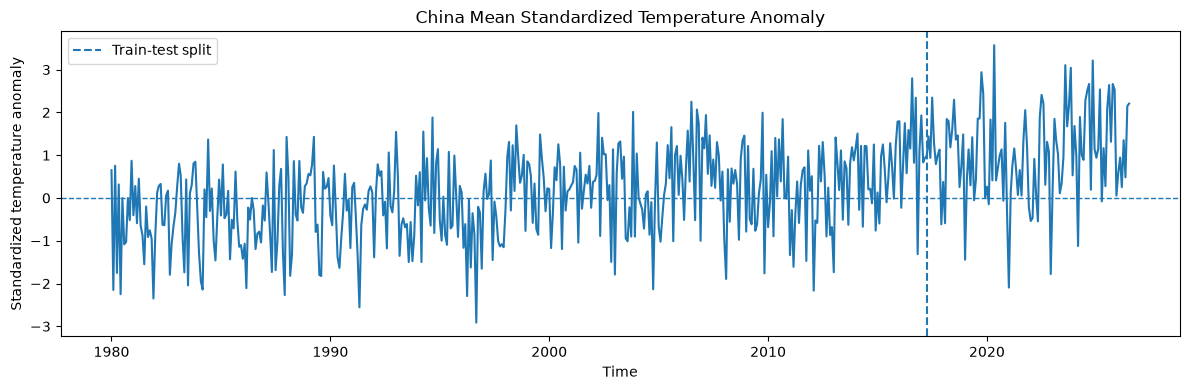

In [21]:
# draw standardized anomaly
plt.figure(
    figsize=(12, 4)
)

plt.plot(
    df["valid_time"],
    df["temp_z"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    split_time,
    linestyle="--",
    label="Train-test split"
)

plt.xlabel("Time")
plt.ylabel(
    "Standardized temperature anomaly"
)

plt.title(
    "China Mean Standardized Temperature Anomaly"
)

plt.legend()

plt.tight_layout()
plt.show()

In [23]:
#define extreme warm month
train_for_threshold = df[
    df["valid_time"] < split_time
].copy()

extreme_thresholds = (
    train_for_threshold
    .groupby("month")["temp_z"]
    .quantile(0.90)
)

extreme_thresholds
df["extreme_threshold"] = (
    df["month"]
    .map(extreme_thresholds)
)

df["extreme_warm"] = (
    df["temp_z"]
    > df["extreme_threshold"]
).astype(int)

#examine extreme frequency
train_events = df[
    df["valid_time"] < split_time
]

test_events = df[
    df["valid_time"] >= split_time
]

print(
    "Training extreme-event ratio:",
    train_events["extreme_warm"].mean()
)

print(
    "Testing extreme-event ratio:",
    test_events["extreme_warm"].mean()
)

print(
    "Training extremes:",
    train_events["extreme_warm"].sum()
)

print(
    "Testing extremes:",
    test_events["extreme_warm"].sum()
)

Training extreme-event ratio: 0.10738255033557047
Testing extreme-event ratio: 0.42857142857142855
Training extremes: 48
Testing extremes: 48


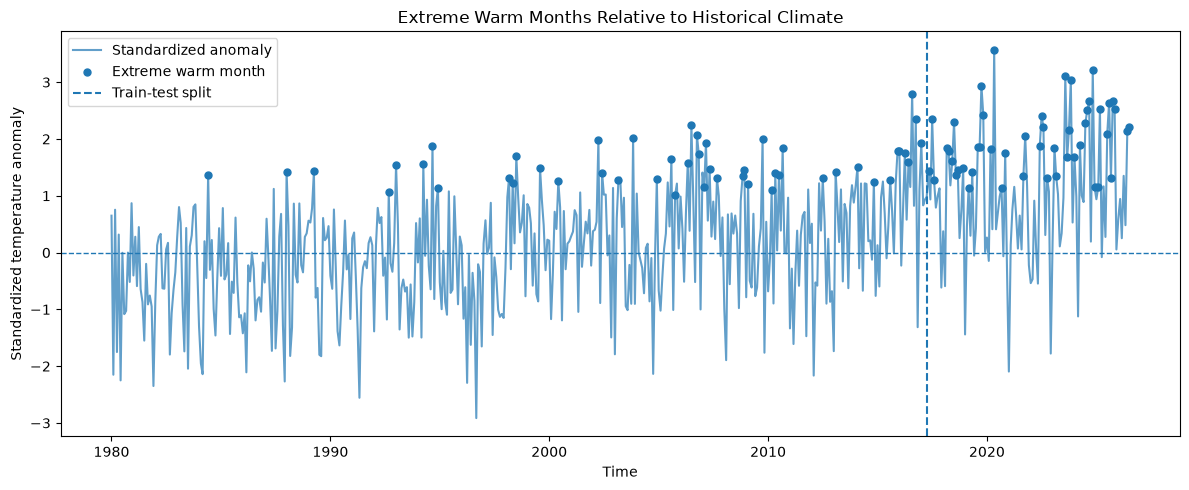

In [24]:
# draw extreme events
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    df["valid_time"],
    df["temp_z"],
    label="Standardized anomaly",
    alpha=0.7
)

extreme_points = df[
    df["extreme_warm"] == 1
]

plt.scatter(
    extreme_points["valid_time"],
    extreme_points["temp_z"],
    s=25,
    label="Extreme warm month"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    split_time,
    linestyle="--",
    label="Train-test split"
)

plt.xlabel("Time")
plt.ylabel(
    "Standardized temperature anomaly"
)

plt.title(
    "Extreme Warm Months Relative to Historical Climate"
)

plt.legend()

plt.tight_layout()
plt.show()

## 4. Diagnose temporal persistence

Before selecting lagged temperature predictors, temporal correlations are
examined in the training period.

This avoids arbitrarily assuming that the previous one, two, or three months
contain useful predictive information.

Lag selection is performed using the training data only.

In [25]:
#calculate lag correlation
train_series = (
    df.loc[
        df["valid_time"] < split_time,
        "temp_z"
    ]
    .copy()
)

lag_correlations = {}

for lag in range(1, 13):

    lag_correlations[lag] = (
        train_series.corr(
            train_series.shift(lag)
        )
    )

lag_corr_df = pd.DataFrame({
    "lag_months": lag_correlations.keys(),
    "correlation": lag_correlations.values()
})

lag_corr_df

,lag_months,correlation
0,1,0.152593
1,2,0.243429
2,3,0.153433
3,4,0.135402
4,5,0.120808
5,6,0.119998
6,7,0.213040
7,8,0.151283
8,9,0.218782
9,10,0.123366


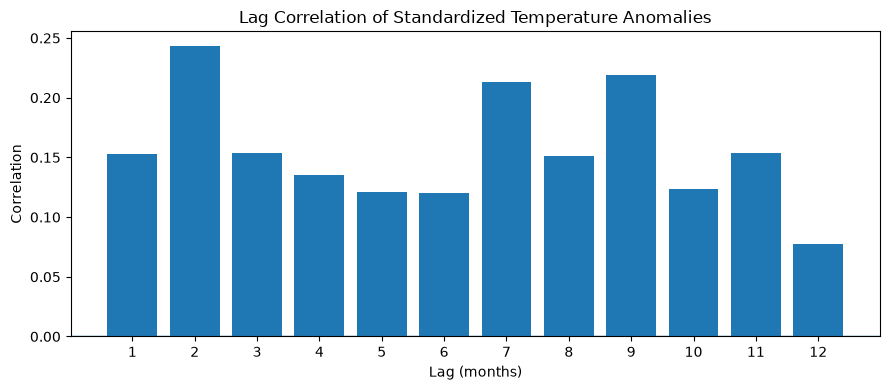

In [26]:
# draw lag correlation
plt.figure(
    figsize=(9, 4)
)

plt.bar(
    lag_corr_df["lag_months"],
    lag_corr_df["correlation"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Lag (months)")
plt.ylabel("Correlation")

plt.title(
    "Lag Correlation of Standardized Temperature Anomalies"
)

plt.xticks(
    range(1, 13)
)

plt.tight_layout()
plt.show()

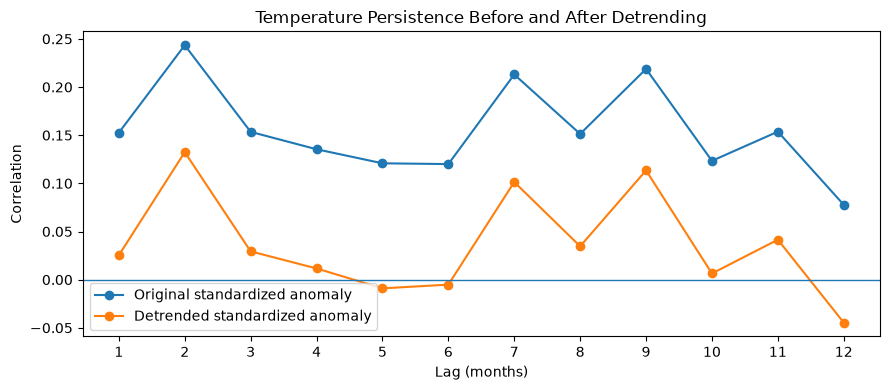

In [29]:
#test
train_diag = df[
    df["valid_time"] < split_time
][
    ["valid_time", "temp_z"]
].copy()

train_diag["time_index"] = (
    np.arange(len(train_diag))
)

trend_coef = np.polyfit(
    train_diag["time_index"],
    train_diag["temp_z"],
    1
)

train_diag["trend"] = (
    trend_coef[0]
    * train_diag["time_index"]
    + trend_coef[1]
)

train_diag["temp_z_detrended"] = (
    train_diag["temp_z"]
    - train_diag["trend"]
)
detrended_lag_corr = {}

for lag in range(1, 13):

    detrended_lag_corr[lag] = (
        train_diag["temp_z_detrended"]
        .corr(
            train_diag[
                "temp_z_detrended"
            ].shift(lag)
        )
    )

detrended_lag_corr_df = pd.DataFrame({
    "lag_months":
        detrended_lag_corr.keys(),

    "correlation":
        detrended_lag_corr.values()
})

detrended_lag_corr_df
plt.figure(
    figsize=(9, 4)
)

plt.plot(
    lag_corr_df["lag_months"],
    lag_corr_df["correlation"],
    marker="o",
    label="Original standardized anomaly"
)

plt.plot(
    detrended_lag_corr_df["lag_months"],
    detrended_lag_corr_df["correlation"],
    marker="o",
    label="Detrended standardized anomaly"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Lag (months)")
plt.ylabel("Correlation")

plt.title(
    "Temperature Persistence Before and After Detrending"
)

plt.xticks(
    range(1, 13)
)

plt.legend()

plt.tight_layout()
plt.show()

### Interpretation of temperature persistence

Before detrending, standardized temperature anomalies show weak positive
correlations across several monthly lags.

However, most of these correlations substantially decrease after removing
the long-term linear trend. In particular, the lag-1 correlation becomes
close to zero.

This indicates that much of the apparent temporal persistence is associated
with the long-term warming signal rather than strong month-to-month
temperature memory.

Therefore, lagged temperature variables are not selected solely on the basis
of the largest sample correlation. Instead, a simple current-temperature
model is retained as a transparent temperature-only benchmark.

In [31]:
# build one-month-ahead target
df["target_extreme_next_month"] = (
    df["extreme_warm"].shift(-1)
)

df["target_time"] = (
    df["valid_time"].shift(-1)
)
df[
    [
        "valid_time",
        "temp_z",
        "extreme_warm",
        "target_time",
        "target_extreme_next_month"
    ]
].tail(10)

#temperature only feature
feature_cols = [
    "temp_z"
]
model_df = df[
    [
        "valid_time",
        "target_time",
        "target_extreme_next_month",
        "temp_z",
        "extreme_warm"
    ]
].dropna().copy()

In [32]:
# split with target time
train_df = model_df[
    model_df["target_time"] < split_time
].copy()

test_df = model_df[
    model_df["target_time"] >= split_time
].copy()

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

y_train = (
    train_df[
        "target_extreme_next_month"
    ].astype(int)
)

y_test = (
    test_df[
        "target_extreme_next_month"
    ].astype(int)
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

print(
    "Training positive ratio:",
    y_train.mean()
)

print(
    "Testing positive ratio:",
    y_test.mean()
)

Training samples: 446
Testing samples: 112
Training positive ratio: 0.10762331838565023
Testing positive ratio: 0.42857142857142855


In [33]:
# Naive baseline
y_pred_naive = np.zeros(
    len(y_test),
    dtype=int
)

naive_accuracy = accuracy_score(
    y_test,
    y_pred_naive
)

naive_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        y_pred_naive
    )
)

print(
    "Naive accuracy:",
    naive_accuracy
)

print(
    "Naive balanced accuracy:",
    naive_balanced_accuracy
)

Naive accuracy: 0.5714285714285714
Naive balanced accuracy: 0.5


In [34]:
# Persistence baseline
y_pred_persistence = (
    test_df[
        "extreme_warm"
    ].astype(int).values
)

print(
    "Persistence accuracy:",
    accuracy_score(
        y_test,
        y_pred_persistence
    )
)

print(
    "Persistence balanced accuracy:",
    balanced_accuracy_score(
        y_test,
        y_pred_persistence
    )
)

Persistence accuracy: 0.5803571428571429
Persistence balanced accuracy: 0.5703125


Accuracy: 0.5
Balanced accuracy: 0.546875
Precision: 0.45652173913043476
Recall: 0.875
F1: 0.6
ROC-AUC: 0.5917968749999999
PR-AUC: 0.5269225790360219


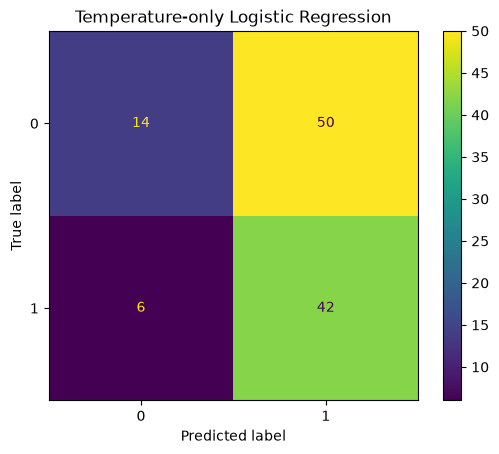

In [37]:
# Temperature-only Logistic Regression
temperature_lr = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            random_state=42
        )
    )
])

temperature_lr.fit(
    X_train,
    y_train
)

temp_prob = (
    temperature_lr
    .predict_proba(X_test)[:, 1]
)

temp_pred = (
    temp_prob >= 0.5
).astype(int)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        temp_pred
    )
)

print(
    "Balanced accuracy:",
    balanced_accuracy_score(
        y_test,
        temp_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        temp_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        temp_pred
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        temp_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        temp_prob
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        temp_prob
    )
)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    temp_pred
)

plt.title(
    "Temperature-only Logistic Regression"
)

plt.show()

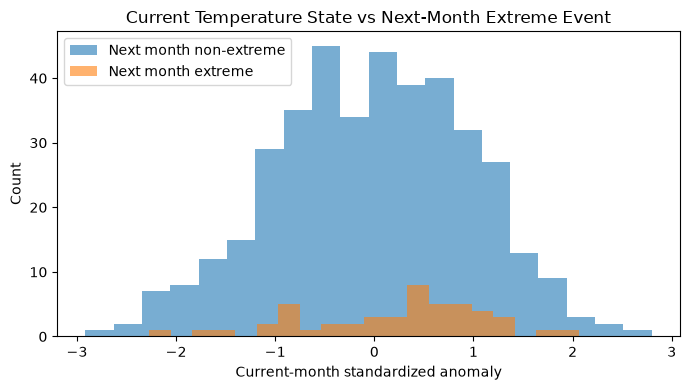

In [38]:
plt.figure(
    figsize=(7, 4)
)

plt.hist(
    train_df.loc[
        y_train == 0,
        "temp_z"
    ],
    bins=20,
    alpha=0.6,
    label="Next month non-extreme"
)

plt.hist(
    train_df.loc[
        y_train == 1,
        "temp_z"
    ],
    bins=20,
    alpha=0.6,
    label="Next month extreme"
)

plt.xlabel(
    "Current-month standardized anomaly"
)

plt.ylabel("Count")

plt.title(
    "Current Temperature State vs Next-Month Extreme Event"
)

plt.legend()

plt.tight_layout()
plt.show()

## 6. Diagnose the contribution of long-term warming

The temperature-only model shows modest discrimination, despite very weak
lag-1 correlation after detrending.

This raises an important question:

> Is the apparent predictive skill associated with short-term temperature
> persistence, or does it mainly reflect the long-term warming trend?

To investigate this, a trend-only model and a detrended-temperature model
are compared with the original temperature-only model.